In [1]:
""" Plot the warming effect on soil mineral nutrients for hummock and hollow separately
"""
import numpy as np
import os
import pandas as pd
import xarray as xr
from glob import glob
import matplotlib.pyplot as plt
import itertools as it
from scipy.stats import linregress
from matplotlib.cm import get_cmap
from utils.constants import chamber_levels_complete
import matplotlib.ticker as ticker
import itertools as it
from matplotlib import rcParams
from matplotlib.colors import BoundaryNorm
from utils.analysis import uq_get_obs, uq_get_sim
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter

rcParams['font.size'] = 12
rcParams['axes.titlesize'] = 12

pft_names = ['Spruce', 'Tamarack', 'Shrub']

outdir = os.path.join(os.environ['PROJDIR'], 'ELM_Phenology', 'output', 'extract')

chambers_ordered = {
    'amb': ['7', '6', '20', '13', '8', '17'],
    'elev': ['19', '11', '4', '16', '10']
}

xticklabels = ['TAMB', 'T0.00', 'T2.25','T4.50', 'T6.75', 'T9.00', 
               'T0.00CO2', 'T2.25CO2', 'T4.5CO2', 'T6.75CO2', 'T9.00CO2']
labs = 'abcdefghijklmnopqrstuvwxyz'

In [2]:
#########################################################################
# Read the N & P uptake fractions from optimal models
#########################################################################
collection_gs = {}

for prefix in ['20231116', 'UQ_20231118', 'UQ_20240107', 'UQ_20240112']:
    temp_data = pd.read_csv(os.path.join(outdir, prefix, 'analysis_ts.csv'),
                                         header = [0, 1, 2, 3], index_col = 0, parse_dates=True)

    # restrict BTRAN & ZWT to growing season
    for col in temp_data.columns:
        if col[1] in ['BTRAN','ZWT']:
            temp_data.loc[(temp_data.index.month < 5) | (temp_data.index.month > 10), col] = np.nan

    # ratio of total nutrient uptake to AVAILC

    # 0 - hummock, 1 - hollow
    for i,hum in enumerate(['hummock','hollow']):
        temp_data2 = temp_data.groupby(['plot','variable','pft'], axis = 1
            ).apply(lambda df: df.iloc[:,i])

        ## ~~Restrict all to growing season
        ## ~~filt = (temp_data.index.month >= 5) & (temp_data.index.month <= 10)
        # No, use whole year!
        filt = (temp_data2.index.month >= 1) & (temp_data2.index.month <= 12)
        # Limit to < 2021 to be consistent with Paul's data
        filt = filt & (temp_data2.index.year <= 2021)
        collection_gs[(prefix, hum)] = temp_data2.loc[filt, :]
    collection_gs[(prefix, 'average')] = collection_gs[(prefix, 'hummock')] * 0.64 + \
                                         collection_gs[(prefix, 'hollow')] * 0.36

/tmp/ipykernel_3940010/1081106230.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data2 = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_3940010/1081106230.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data2 = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_3940010/1081106230.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data2 = temp_data.groupby(['plot','variable','pft'], axis = 1
/tmp/ipykernel_3940010/1081106230.py:19: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  temp_data2 = temp_data.groupby(['plot','variable','pft'], axis = 1


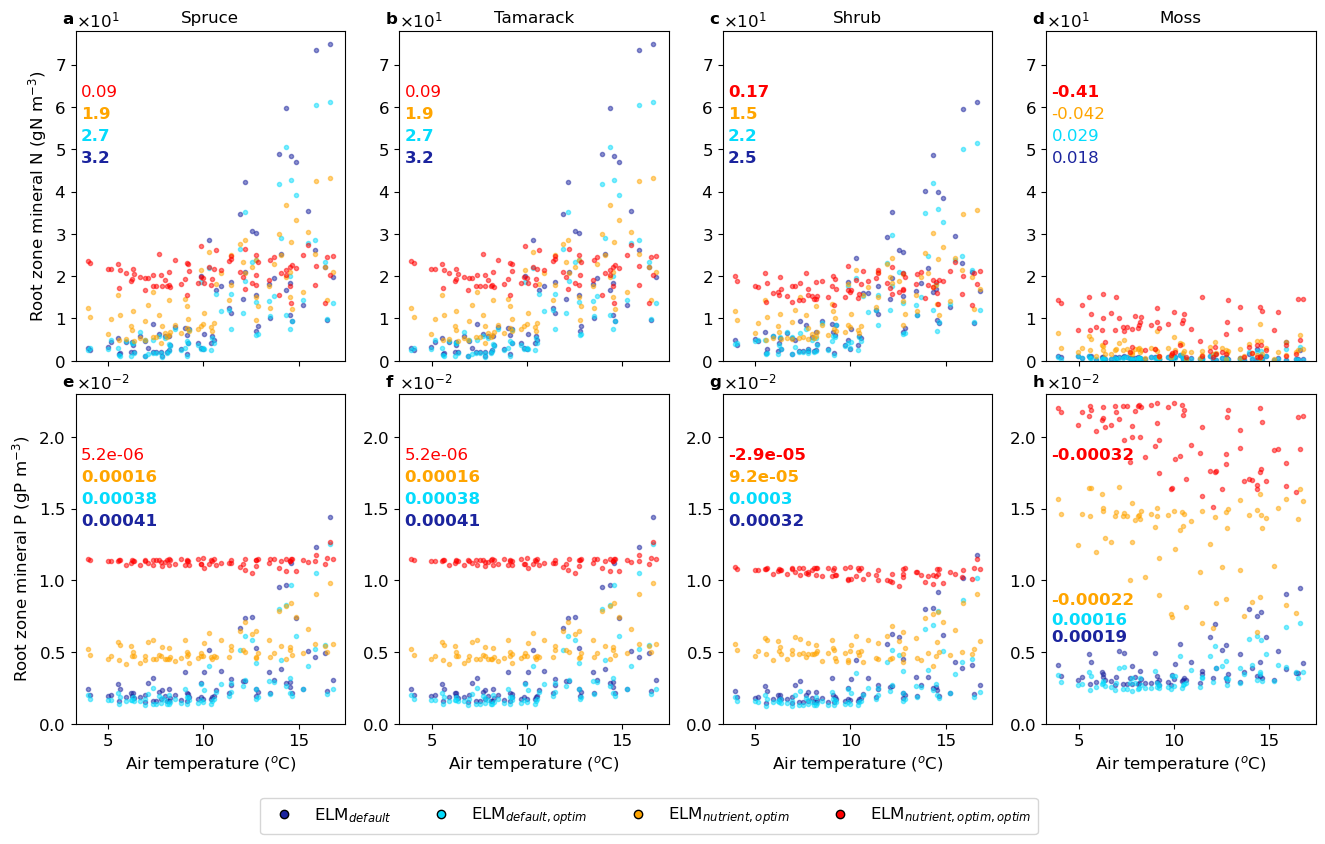

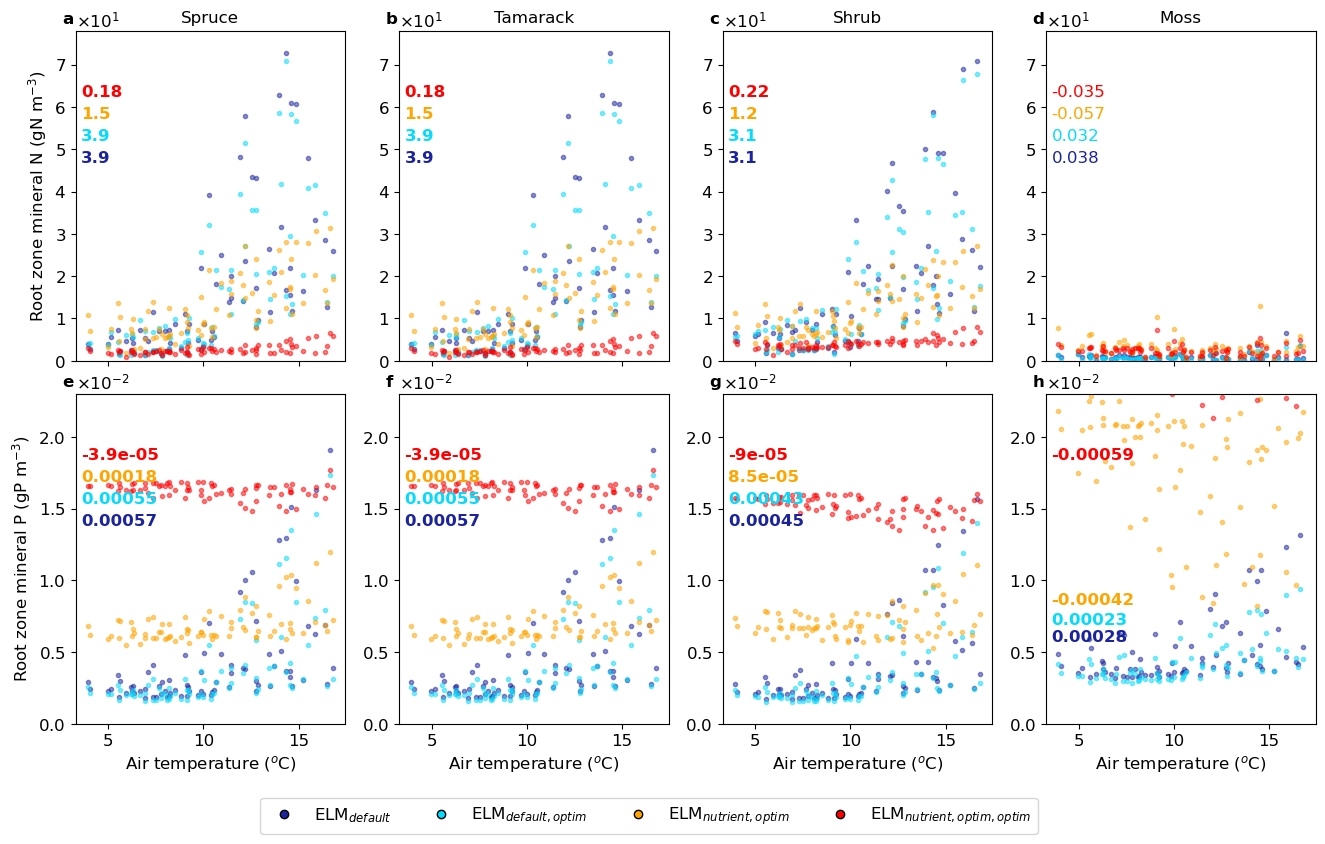

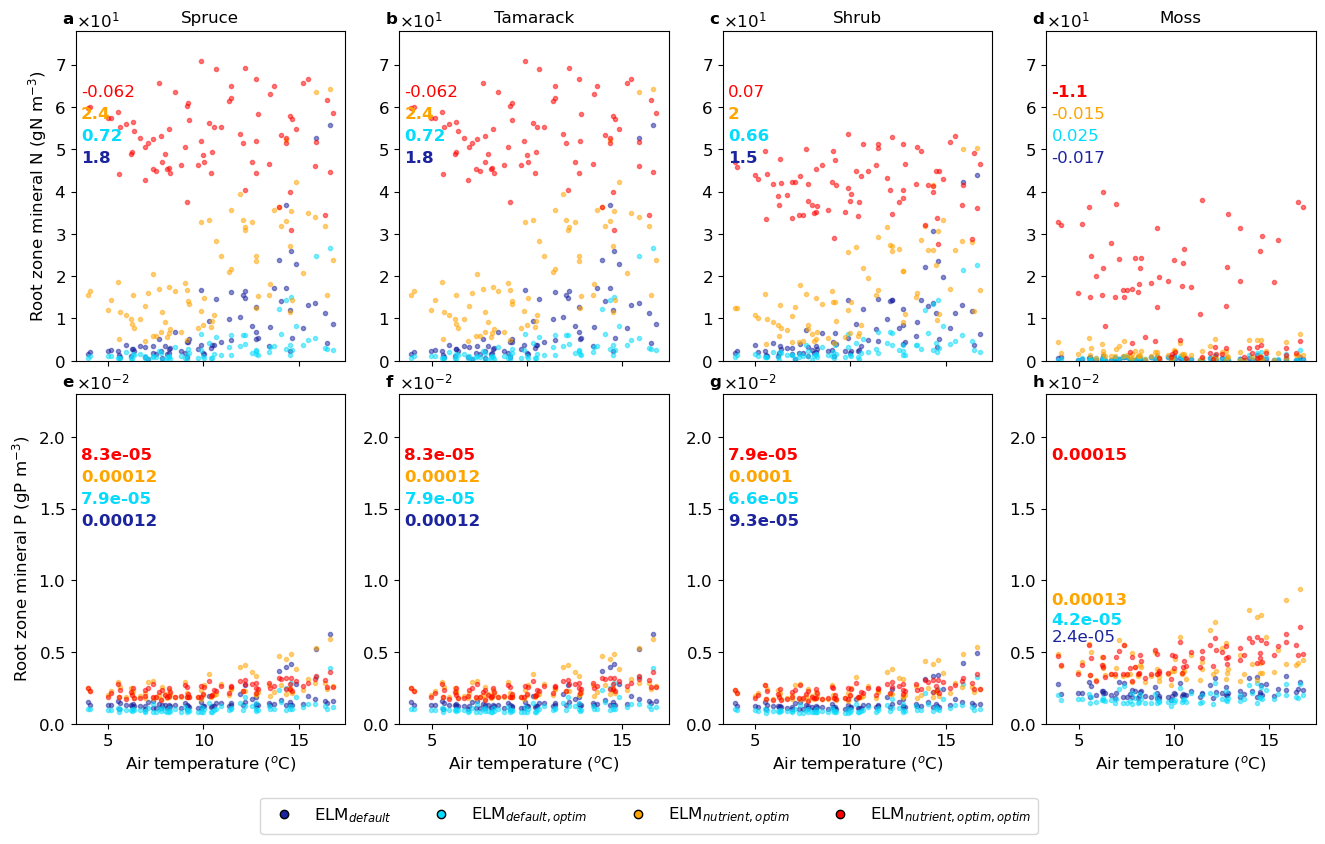

In [ ]:
#########################################################################
# Root zone mineral nutrient's relationship with air temperature
#########################################################################
for loc in ['average', 'hummock', 'hollow']:
    fig, axes = plt.subplots(2, 4, figsize = (16, 9), sharex = True, sharey = False)
    fig.subplots_adjust(hspace = 0.1)
    for j, nu in enumerate(['N','P']):
        if nu == 'N':
            nu_var = 'SMINN_vr_ROOTFR'
        else:
            nu_var = 'SOLUTIONP_vr_ROOTFR'

        for i, (pft,name) in enumerate(zip(['2','3','11','12'],
                                            ['Spruce','Tamarack','Shrub','Moss'])):

            ax = axes[j, i]

            for p, (prefix, pname, colr) in \
                enumerate(zip(['20231116', 'UQ_20231118', 'UQ_20240107', 'UQ_20240112'],
                            ['ELM$_{default}$', 'ELM$_{default,optim}$',
                            'ELM$_{nutrient,optim}$', 'ELM$_{nutrient,optim,optim}$'], 
                            ['#1b249e', '#05dbfc', '#ffa500', '#ff0000'])):

                # soil nutrient status
                sminn = collection_gs[(prefix, loc)].loc[:, (slice(None), nu_var, pft)]
                # air temperature
                tair = collection_gs[(prefix, loc)].loc[:, (slice(None), 'TBOT', '0')]

                # average to annual values
                # (the seasonal values are affected by the noise of seasonality)
                sminn = sminn.resample('1Y').mean()
                tair = tair.resample('1Y').mean()

                ax.plot(tair.values.reshape(-1), sminn.values.reshape(-1), 'o',
                        color = colr, markersize = 3, alpha = 0.5)

                ax.plot(np.nan, np.nan, 'o', color = colr, 
                        markersize = 6, label = pname, markeredgecolor = 'k')
                
                res = linregress(tair.values.reshape(-1), sminn.values.reshape(-1))
                if res.pvalue <= 0.05:
                    fontdict = {'weight': 'bold'}
                else:
                    fontdict = {}
                xpos = 0.02
                if (i <= 2) | (j == 0):
                    ypos = 0.6 + p/15
                else:
                    if p == 3:
                        ypos = 0.8
                    elif p == 2:
                        ypos = 0.36
                    else:
                        ypos = 0.25+p/20

                ax.text(xpos, ypos, f'{res.slope:0.2g}', color = colr,
                        fontdict = fontdict, transform = ax.transAxes)

            if i == 0:
                if nu == 'N':
                    ax.set_ylabel(f'Root zone mineral {nu} (g{nu} ' + 'm$^{-3}$)')
                else:
                    ax.set_ylabel(f'Root zone mineral {nu} (g' + f'{nu} ' + 'm$^{-3}$)')

            if (j == 1) & (i == 3):
                ax.legend(ncol = 4, bbox_to_anchor = (0, -0.2))

            if j == 0:
                ax.set_title(name)
                ax.set_ylim([-1e-3, 78])
            else:
                ax.set_xlabel('Air temperature ($^o$C)')
                ax.set_ylim([0, 0.023])

            ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
            ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax.text(-0.05, 1.02, labs[j*4+i], fontdict={'weight':'bold'}, transform = ax.transAxes)